[2026-07-21 15:11:05] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59 | mode=ensemble
[2026-07-21 15:11:05] [info     ] GP 因子构建                        formula="rank(sub(col('profit_growth_20'), col('amihud_1')))" mode=ensemble n_ensemble=17 test_end='2024-12-31 23:59:59' test_start='2024-01-01 00:00:00' train_end='2023-06-30 23:59:59' train_start='2021-01-01 00:00:00'
[2026-07-21 15:11:05] [info     ] build_factor_panel 开始          end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-21 15:11:08] [info     ] 财务字段完成                         elapsed=2.83 rows=2491208
[2026-07-21 15:11:11] [info     ] 量价字段完成                         elapsed=2.98 rows=657209
[2026-07-21 15:11:17] [info     ] build_factor_panel 结束          elapsed=11.21 rows=526680
[2026-07-21 15:11:17] [info     ] 因子模式 ensemble                  n_seeds=17
[2026-07-21 15:11:25] [info     ] 因子构建完成                         mode=ensemble rows=242000
[2026-07-21 15:11:25] [info     ] 读取因子库，区间：2024-01-01 0

时段,IC
2024-01-15~2024-02-08,0.0149
2024-09-24~2024-10-08,0.0141

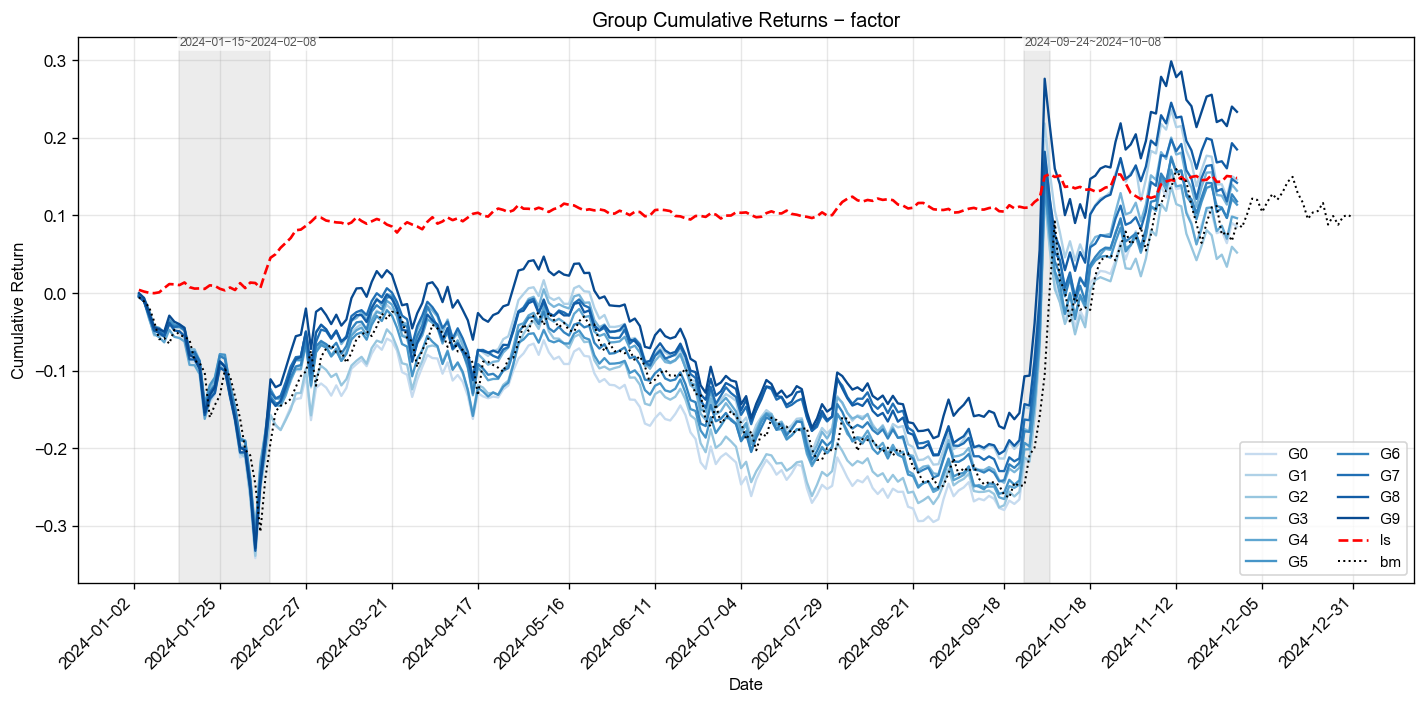
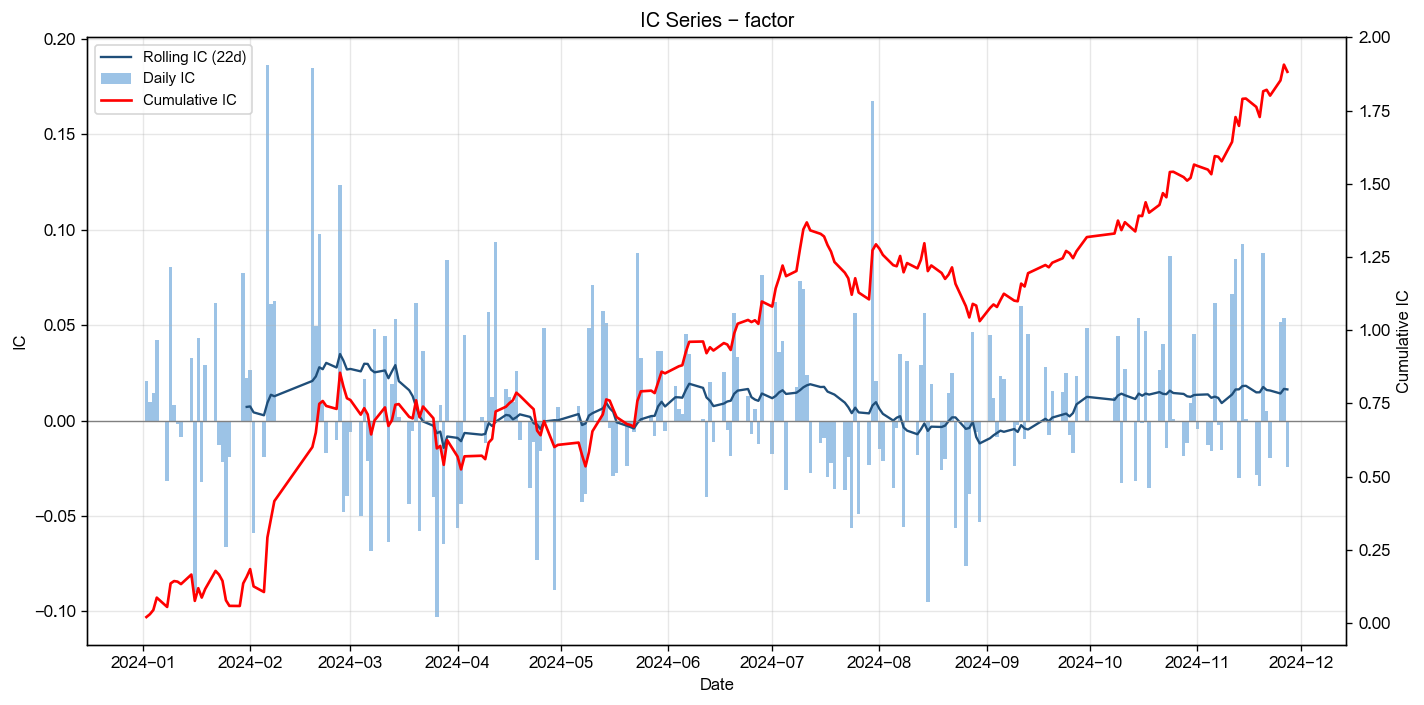
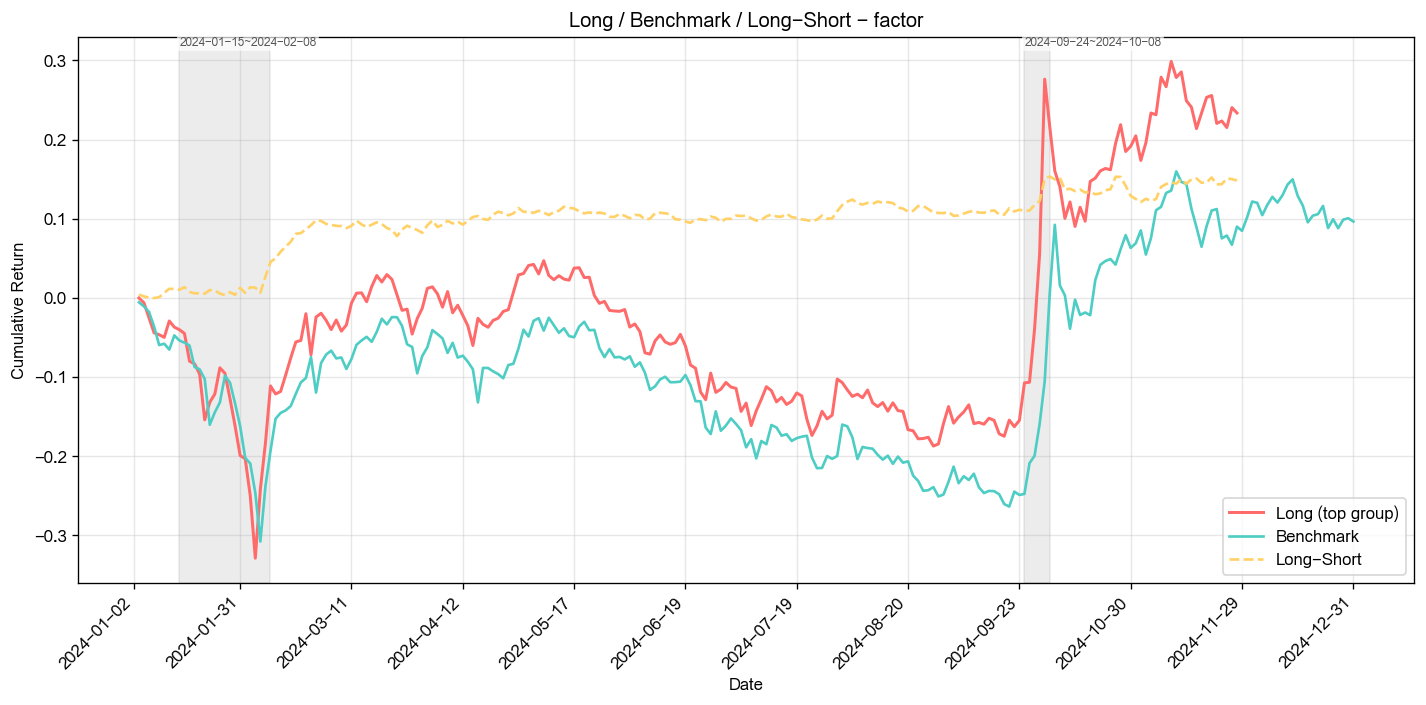
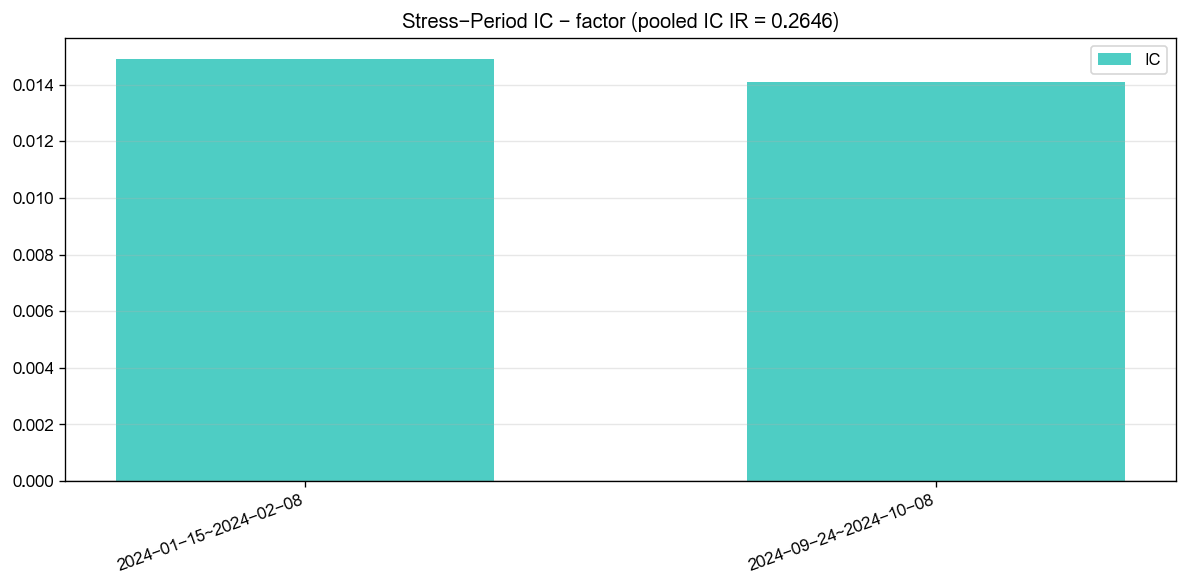
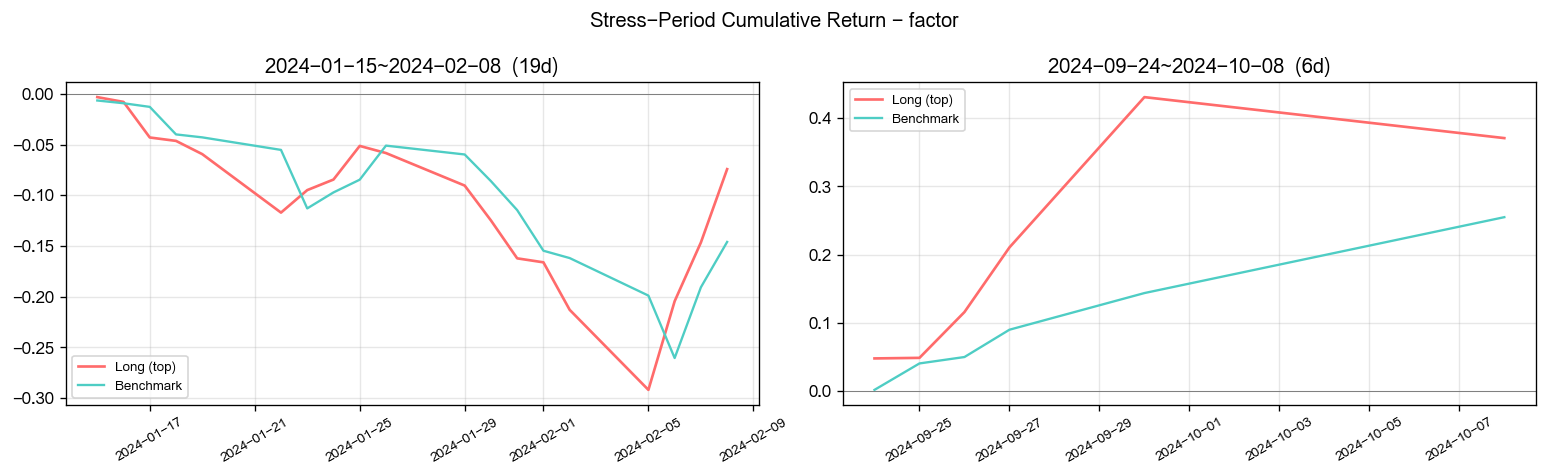

[2026-07-21 15:11:40] [info     ] ========== 因子池回归 ==========
[2026-07-21 15:11:41] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-21 15:11:43] [info     ] 获取收益率数据, 耗时: 2.3637 秒
[2026-07-21 15:11:43] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.3616 秒
[2026-07-21 15:11:43] [info     ] 统计 回归结果, 耗时: 0.008 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9438,0.0446,0.0229,1.0000
2,amount,1.6835,0.0185,0.0110,1.0000
3,netflow_amount_rate_main,1.5433,0.0099,0.0064,1.0000
4,net_profit_rate_ttm,1.5365,0.0041,0.0026,0.9000
5,netflow_amount_main,1.5090,0.0252,0.0167,1.0000
6,gross_profit_rate_ttm,1.5025,0.0069,0.0046,1.0000
7,factor,1.4793,0.0045,0.0030,0.9000
8,pb,1.4355,0.0097,0.0068,1.0000
9,bias_20,1.4188,0.0291,0.0205,0.9000
10,cci_14,1.3913,0.0340,0.0244,1.0000

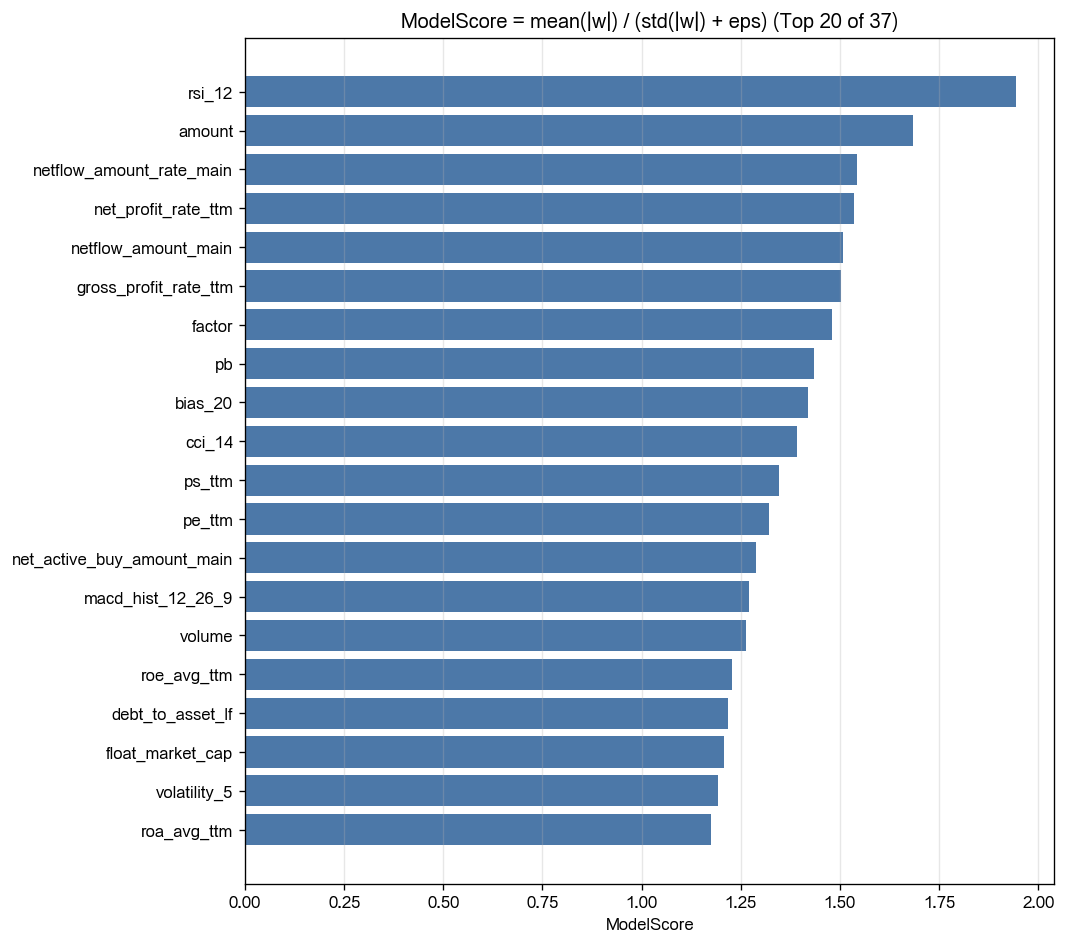
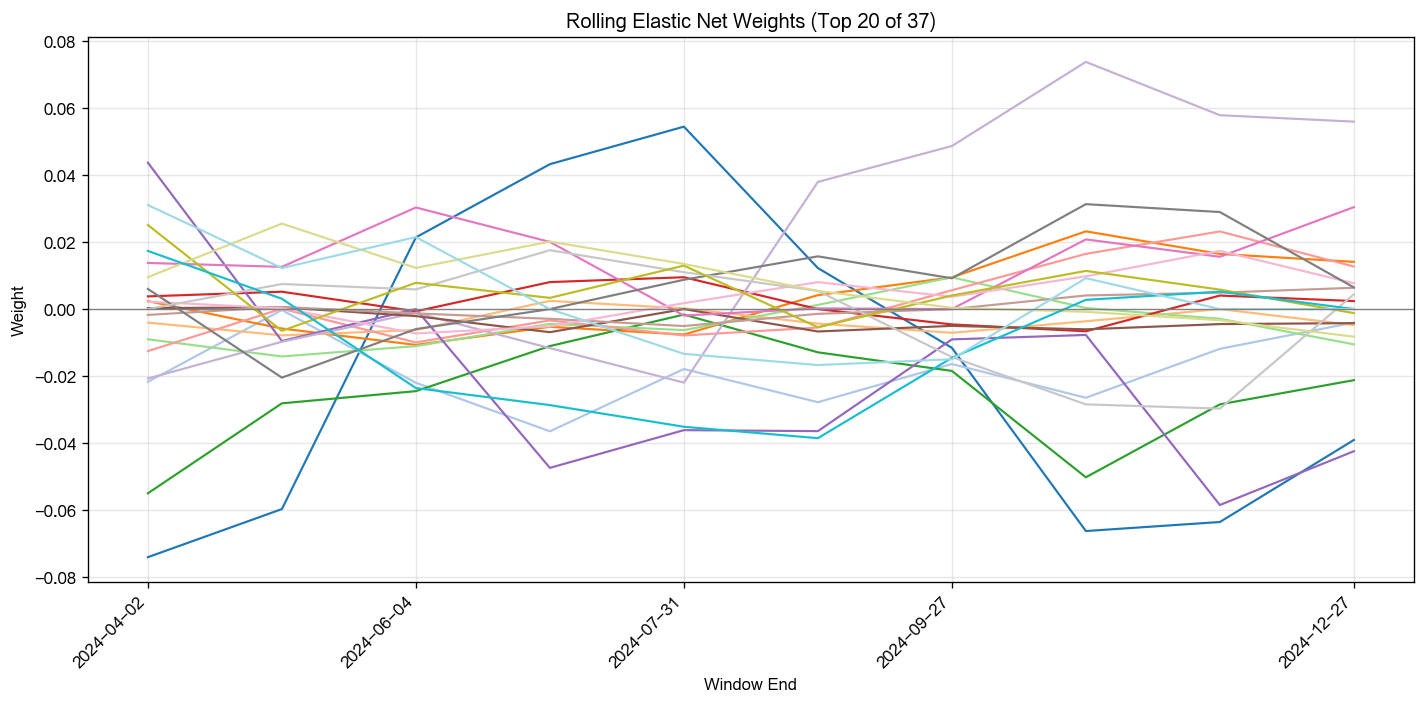
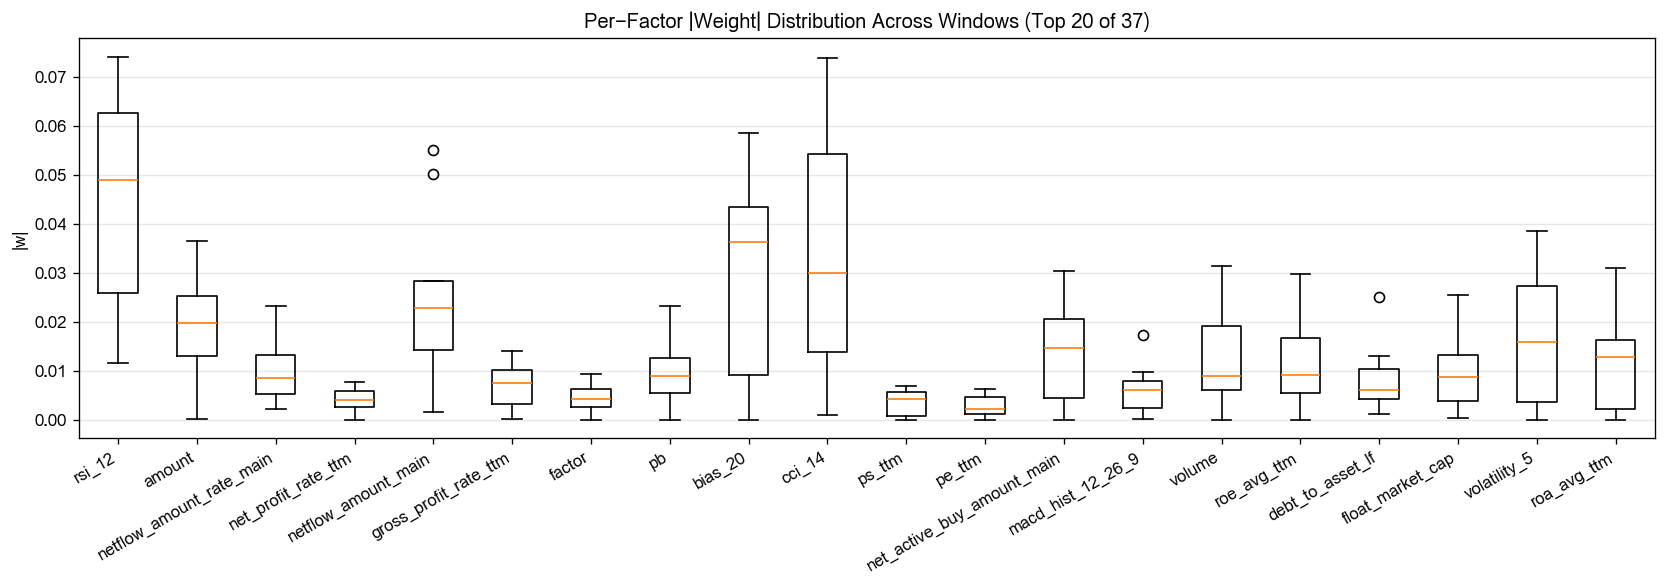
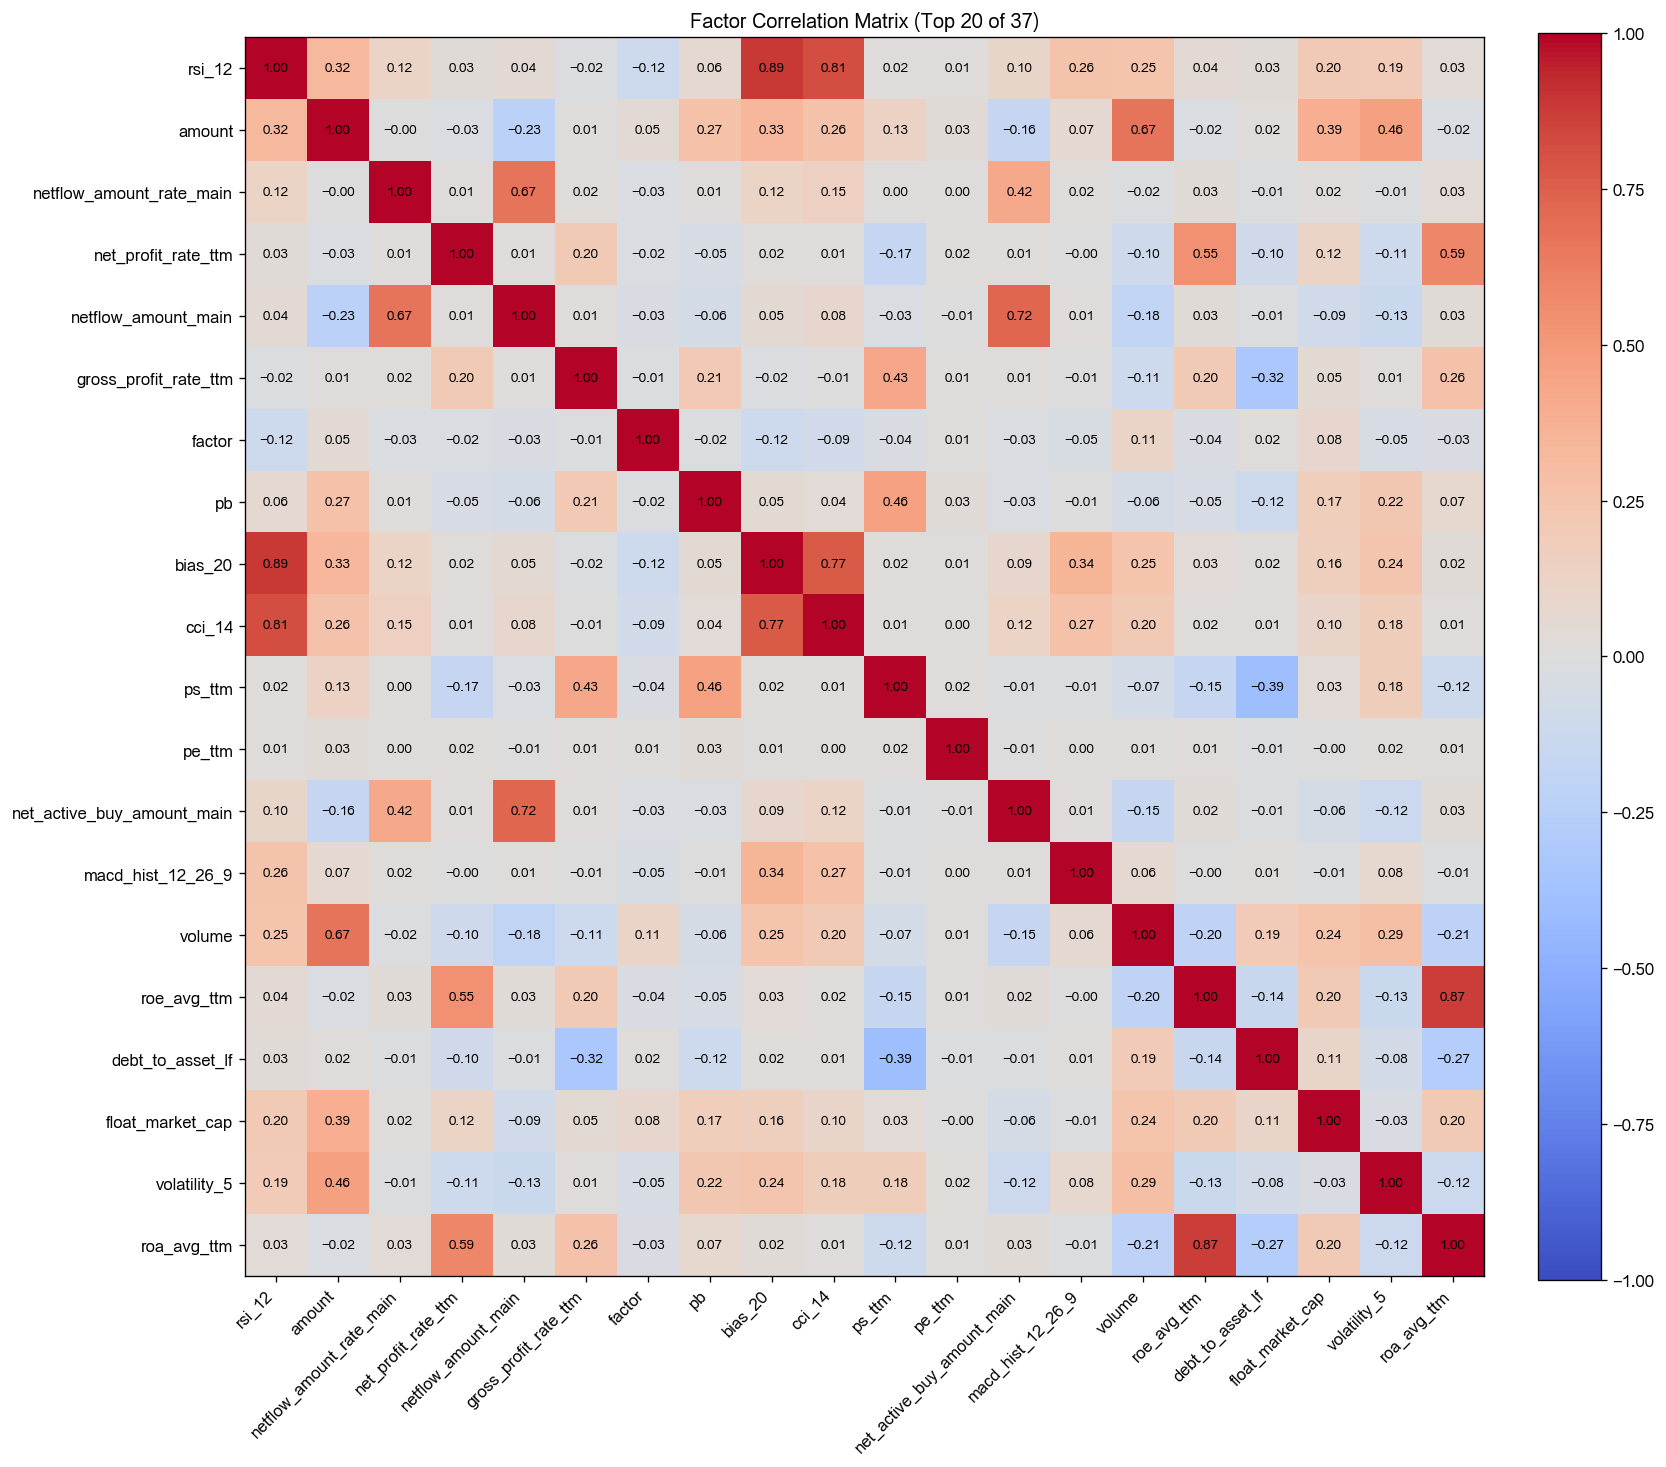

[2026-07-21 15:11:45] [warning  ] 返回的Outputs实例(size=33537150) 大于 64K, 将不会被缓存
[2026-07-21 15:11:45] [info     ] bigalpha_eval.v4 运行完成 [17.629s].


In [4]:
"""
BigAlpha 2026 GP 因子（提交版）

默认提交：profit_growth_20 − amihud_1（2024 OOS ic≈0.0066）
另含 Alpha101/GTJA 翻译种子；可将 FACTOR_MODE 改为 'ensemble' 做等权融合（需先 OOS 验证）。
"""

# ---------------------------------------------------------------------------
# 因子公式配置
# ---------------------------------------------------------------------------

# 公榜默认（已验证）
BEST_FORMULA = "rank(sub(col('profit_growth_20'), col('amihud_1')))"

# 'primary' = 只交 BEST_FORMULA；'ensemble' = 种子等权截面 rank 融合
FACTOR_MODE ='ensemble'

RUNNER_UP_FORMULA = (
    "rank(sub(col('rev_growth_20'), add(col('amihud_1'), col('asset_growth_20'))))"
)
FUSION_FORMULA = (
    "rank(add("
    "sub(col('profit_growth_20'), col('amihud_1')), "
    "sub(col('rev_growth_20'), add(col('amihud_1'), col('asset_growth_20')))"
    "))"
)

# Alpha101 / GTJA 可翻译近似（见 alpha_seed_translate.py / docs/factor_calendar_usable.tex）
TRANSLATED_SEED_FORMULAS: list[str] = [
    "rank(mul(neg(ts_pct('close', 1)), ts_pct('volume', 1)))",
    "rank(div(sub(col('high'), col('low')), col('close')))",
    "rank(neg(div(sub(col('close'), col('low')), add(sub(col('high'), col('low')), 1e-8))))",
    "rank(neg(ts_pct('close', 1)))",
    "rank(sub(ts_pct('close', 1), ts_pct('close', 20)))",
    "rank(div(ts_pct('close', 5), ts_pct('volume', 5)))",
    "rank(neg(col('overnight_ret')))",
    "rank(neg(ts_std('close', 20)))",
    "rank(div(ts_pct('close', 5), ts_std('close', 20)))",
    "rank(div(sub(col('close'), col('open')), col('open')))",
    "rank(neg(ts_pct('close', 5)))",
    "rank(col('volume_ratio_5'))",
    "rank(neg(col('hl_range')))",
    "rank(neg(col('amihud_1')))",
]

ENSEMBLE_FORMULAS: list[str] = [
    BEST_FORMULA,
    RUNNER_UP_FORMULA,
    FUSION_FORMULA,
    *TRANSLATED_SEED_FORMULAS,
]

FIN_LOOKBACK_DAYS = 730
PRICE_LOOKBACK_DAYS = 90
FIN_GROWTH_LAG = 60
FACTOR_FFILL_LIMIT = 20
NEUTRAL_RANK = 0.5
SMOOTH_WINDOW = 5


def ensure_instrument_str(df: object) -> object:
    """compression=True 后 instrument 可能为 category，统一成 str。"""
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')
    if 'instrument' in df.columns:
        df = df.copy()
        df['instrument'] = df['instrument'].astype(str)
    return df


def dai_query_df(
    sql: str,
    filters: dict[str, object] | None = None,
    *,
    compression: bool = True,
) -> object:
    """DAI 查询：默认 compression=True；instrument → str。"""
    import dai

    kwargs: dict[str, object] = {'compression': compression}
    if filters is not None:
        kwargs['filters'] = filters
    return ensure_instrument_str(dai.query(sql, **kwargs).df())


def build_factor_panel(
    financial_table: str,
    bar1m_table: str,
    sd: str,
    ed: str,
    logger: object | None = None,
) -> object:
    """量价日频 + 财务 ffill + 日历特征（含翻译种子所需列）。"""
    import time

    import numpy as np
    import pandas as pd

    price_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
    fin_cols = [
        'net_profit_to_parent_shareholders',
        'operating_revenue',
        'total_assets',
    ]

    t0 = time.time()
    if logger is not None:
        logger.info('build_factor_panel 开始', start=str(sd), end=str(ed))

    fin_start = pd.to_datetime(sd) - pd.Timedelta(days=FIN_LOOKBACK_DAYS)
    fin_sql = f"""
    SELECT date, instrument::string AS instrument, {', '.join(fin_cols)}
    FROM {financial_table}
    WHERE category='lf' AND shift=0
    """
    fin = dai_query_df(fin_sql, filters={'date': [fin_start, ed]}, compression=True)

    def fill_natural_dates(df: pd.DataFrame, fill_sd: object, fill_ed: object) -> pd.DataFrame:
        natural_dates = pd.date_range(start=fill_sd, end=fill_ed)
        df = df.set_index('date')

        def reindex_and_fill(group_df: pd.DataFrame) -> pd.DataFrame:
            filled_df = group_df.reindex(natural_dates).ffill()
            filled_df['instrument'] = str(group_df.name)
            return filled_df

        df_filled = df.groupby('instrument', group_keys=False).apply(reindex_and_fill)
        return (
            df_filled.reset_index()
            .rename(columns={'index': 'date'})
            .dropna(subset=['instrument'])
        )

    fin = fill_natural_dates(fin, fin_start, ed)
    fin = ensure_instrument_str(fin)
    fin['date'] = pd.to_datetime(fin['date'])
    if logger is not None:
        logger.info('财务字段完成', rows=len(fin), elapsed=round(time.time() - t0, 2))

    t1 = time.time()
    price_start = pd.to_datetime(sd) - pd.Timedelta(days=PRICE_LOOKBACK_DAYS)
    price_sql = f"""
    SELECT
        date_trunc('day', date)::DATE           AS trading_day,
        instrument::string                      AS instrument,
        ARG_MIN(open, date)                     AS open,
        MAX(high)                               AS high,
        MIN(low)                                AS low,
        ARG_MAX(close, date)                    AS close,
        SUM(volume)                             AS volume,
        SUM(amount)                             AS amount
    FROM {bar1m_table}
    GROUP BY date_trunc('day', date)::DATE, instrument::string
    ORDER BY trading_day, instrument
    """
    price = dai_query_df(
        price_sql,
        filters={'date': [price_start, ed]},
        compression=True,
    ).rename(columns={'trading_day': 'date'})
    price['date'] = pd.to_datetime(price['date'])
    price = price.sort_values(['instrument', 'date']).reset_index(drop=True)
    if logger is not None:
        logger.info('量价字段完成', rows=len(price), elapsed=round(time.time() - t1, 2))

    df = pd.merge(price, fin, how='left', on=['date', 'instrument'])
    for col in price_cols + fin_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    for col in fin_cols:
        df[col] = df.groupby('instrument', group_keys=False)[col].ffill()

    df = add_calendar_features(df)
    out = df[(df['date'] >= pd.to_datetime(sd)) & (df['date'] <= pd.to_datetime(ed))]
    if logger is not None:
        logger.info('build_factor_panel 结束', rows=len(out), elapsed=round(time.time() - t0, 2))
    return out.reset_index(drop=True)


def _fin_growth_lag_series(s: object, lag: int) -> object:
    import pandas as pd

    if not isinstance(s, pd.Series):
        raise TypeError('s 必须是 Series')
    lag_s = s.shift(int(lag))
    denom = lag_s.abs().clip(lower=1e-8)
    return (s - lag_s) / denom


def add_calendar_features(df: object) -> object:
    """预计算提交公式 + 翻译种子所需列。"""
    import numpy as np
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')

    out = df.sort_values(['instrument', 'date']).copy()
    inst_g = out.groupby('instrument', group_keys=False)
    g_close = inst_g['close']
    ret_1 = g_close.pct_change(1)

    out['amihud_1'] = ret_1.abs() / out['amount'].replace(0, np.nan)
    out['amihud_1'] = out['amihud_1'].replace([np.inf, -np.inf], np.nan)
    out['amihud_1'] = inst_g['amihud_1'].ffill(limit=10)

    prev_close = g_close.shift(1)
    out['overnight_ret'] = out['open'] / prev_close.replace(0, np.nan) - 1
    out['hl_range'] = (out['high'] - out['low']) / out['close'].replace(0, np.nan)
    out['volume_ratio_5'] = out['volume'] / inst_g['volume'].shift(5).replace(0, np.nan)

    out['profit_growth_20'] = inst_g['net_profit_to_parent_shareholders'].transform(
        lambda s: _fin_growth_lag_series(s, FIN_GROWTH_LAG)
    )
    out['profit_growth_20'] = out['profit_growth_20'].replace([np.inf, -np.inf], np.nan)
    out['profit_growth_20'] = inst_g['profit_growth_20'].ffill()

    if 'operating_revenue' in out.columns:
        out['rev_growth_20'] = inst_g['operating_revenue'].transform(
            lambda s: _fin_growth_lag_series(s, FIN_GROWTH_LAG)
        )
        out['rev_growth_20'] = out['rev_growth_20'].replace([np.inf, -np.inf], np.nan)
        out['rev_growth_20'] = inst_g['rev_growth_20'].ffill()

    if 'total_assets' in out.columns:
        out['asset_growth_20'] = inst_g['total_assets'].transform(
            lambda s: _fin_growth_lag_series(s, FIN_GROWTH_LAG)
        )
        out['asset_growth_20'] = out['asset_growth_20'].replace([np.inf, -np.inf], np.nan)
        out['asset_growth_20'] = inst_g['asset_growth_20'].ffill()

    for c in ('overnight_ret', 'hl_range', 'volume_ratio_5'):
        out[c] = out[c].replace([np.inf, -np.inf], np.nan)

    return out


def fill_factor_values(df: object) -> object:
    """对齐 stk_pool 后填充 factor，并保证每个交易日截面有方差。"""
    import numpy as np
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')

    out = df.sort_values(['instrument', 'date']).copy()
    out['factor'] = pd.to_numeric(out['factor'], errors='coerce')
    out['factor'] = out.groupby('instrument')['factor'].ffill(limit=FACTOR_FFILL_LIMIT)
    out['factor'] = out.groupby('instrument')['factor'].bfill(limit=10)

    def _finalize_cs(x: pd.Series) -> pd.Series:
        s = x.copy()
        if s.notna().sum() == 0:
            n = len(s)
            return pd.Series(np.linspace(0.01, 0.99, n), index=s.index, dtype=float)
        med = float(s.median())
        if med != med:
            med = NEUTRAL_RANK
        s = s.fillna(med)
        if s.nunique() <= 1:
            n = len(s)
            return pd.Series(np.linspace(0.01, 0.99, n), index=s.index, dtype=float)
        return s.rank(pct=True, method='average')

    out['factor'] = out.groupby('date')['factor'].transform(_finalize_cs)
    return out


def eval_formula(df: object, expr: str) -> object:
    """在安全算子集上执行写死的 GP 公式（含翻译种子所需 ts_std）。"""
    import numpy as np
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')

    frame = df.sort_values(['instrument', 'date']).copy()
    inst_g = frame.groupby('instrument', group_keys=False)

    def col(name: str) -> pd.Series:
        if name not in frame.columns:
            raise ValueError(f'未知字段: {name}')
        return frame[name]

    def ts_pct(name: str, n: int) -> pd.Series:
        return inst_g[name].pct_change(int(n))

    def ts_std(name: str, n: int) -> pd.Series:
        return inst_g[name].transform(
            lambda s: s.rolling(int(n), min_periods=max(2, int(n) // 4)).std()
        )

    def rank(x: pd.Series) -> pd.Series:
        s = pd.Series(x, index=frame.index, dtype=float)
        return s.groupby(frame['date']).rank(pct=True, method='average')

    def _as_series(v: object) -> pd.Series:
        if isinstance(v, pd.Series):
            return v
        return pd.Series(float(v), index=frame.index, dtype=float)

    def add(a: object, b: object) -> pd.Series:
        return _as_series(a) + _as_series(b)

    def sub(a: object, b: object) -> pd.Series:
        return _as_series(a) - _as_series(b)

    def mul(a: object, b: object) -> pd.Series:
        return _as_series(a) * _as_series(b)

    def div(a: object, b: object) -> pd.Series:
        return _as_series(a) / _as_series(b).replace(0, np.nan)

    def neg(x: object) -> pd.Series:
        return -_as_series(x)

    safe_globals: dict[str, object] = {'__builtins__': {}}
    safe_locals: dict[str, object] = {
        'col': col,
        'ts_pct': ts_pct,
        'ts_std': ts_std,
        'rank': rank,
        'add': add,
        'sub': sub,
        'mul': mul,
        'div': div,
        'neg': neg,
    }
    out = eval(expr, safe_globals, safe_locals)
    factor = pd.Series(out, index=frame.index, dtype=float)
    return factor.replace([np.inf, -np.inf], np.nan)


def build_factor_series(panel: object, logger: object | None = None) -> object:
    """按 FACTOR_MODE 生成单列因子。"""
    import pandas as pd

    if not isinstance(panel, pd.DataFrame):
        raise TypeError('panel 必须是 DataFrame')

    if FACTOR_MODE == 'primary':
        if logger is not None:
            logger.info('因子模式 primary', formula=BEST_FORMULA)
        return eval_formula(panel, BEST_FORMULA)

    if FACTOR_MODE != 'ensemble':
        raise ValueError(f'未知 FACTOR_MODE={FACTOR_MODE!r}，可选 primary | ensemble')

    if logger is not None:
        logger.info('因子模式 ensemble', n_seeds=len(ENSEMBLE_FORMULAS))

    acc: pd.Series | None = None
    n_ok = 0
    for expr in ENSEMBLE_FORMULAS:
        try:
            raw = eval_formula(panel, expr)
        except Exception as exc:
            if logger is not None:
                logger.warning('种子跳过', formula=expr[:48], error=str(exc))
            continue
        ranked = pd.Series(raw, index=panel.index, dtype=float)
        ranked = ranked.groupby(panel['date']).rank(pct=True, method='average')
        acc = ranked if acc is None else acc.add(ranked, fill_value=0.0)
        n_ok += 1

    if acc is None or n_ok == 0:
        raise RuntimeError('ensemble 无可用种子公式')

    blended = acc / float(n_ok)
    return blended.groupby(panel['date']).rank(pct=True, method='average')


def main(datasources: dict[str, str], start_date: str, end_date: str) -> object:
    """
    BigAlpha 2026 GP 因子（提交版）

    赛制约定:
        start_date / end_date 为【测试集】；公式离线写死，main 内不做进化。

    返回:
        pd.DataFrame: ['date', 'instrument', 'factor']，无 inf
    """
    import numpy as np
    import pandas as pd
    import structlog

    logger = structlog.get_logger()
    train_start = '2021-01-01 00:00:00'
    train_end = '2023-06-30 23:59:59'

    logger.info(
        'GP 因子构建',
        mode=FACTOR_MODE,
        formula=BEST_FORMULA,
        n_ensemble=len(ENSEMBLE_FORMULAS),
        train_start=train_start,
        train_end=train_end,
        test_start=start_date,
        test_end=end_date,
    )

    bar1m_table = datasources['bar1m']
    financial_table = datasources['financial']
    panel = build_factor_panel(financial_table, bar1m_table, start_date, end_date, logger)
    panel['factor'] = build_factor_series(panel, logger)
    panel['factor'] = panel.groupby('instrument')['factor'].transform(
        lambda s: s.rolling(SMOOTH_WINDOW, min_periods=1).mean()
    )

    stk_pool = dai_query_df(
        'SELECT date, instrument::string AS instrument FROM bigalpha_2026_instruments',
        filters={'date': [start_date, end_date]},
        compression=True,
    )
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    panel['date'] = pd.to_datetime(panel['date'])
    panel['instrument'] = panel['instrument'].astype(str)

    result = pd.merge(
        stk_pool,
        panel[['date', 'instrument', 'factor']],
        how='left',
        on=['date', 'instrument'],
    )
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = fill_factor_values(result)
    result = result[['date', 'instrument', 'factor']].reset_index(drop=True)

    logger.info('因子构建完成', rows=len(result), mode=FACTOR_MODE)
    return result


if __name__ == '__main__':
    from bigmodule import M
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial',
    }
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f'计算因子，测试区间：{start_date} ~ {end_date} | mode={FACTOR_MODE}')
    factor_data = main(datasources, start_date, end_date)

    logger.info(f'读取因子库，区间：{start_date} ~ {end_date}')
    factor_pool = dai_query_df(
        'SELECT * FROM bigalpha_2026_factorlib',
        filters={'date': [start_date, end_date]},
        compression=True,
    )

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
        start_date=start_date,
        end_date=end_date,
    )
